In [1]:
import pandas as pd, si_units as si, ternary, matplotlib.pyplot as plt, numpy as np, PLOT_SETTINGS as ps, matplotlib.ticker as ticker, ast, os, feos
from molmass import Formula
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.lines import Line2D
from io import StringIO

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{xcolor}'

In [2]:
# parameters      = feos.Parameters.from_json(["argon", "nitrogen", "hydrogen"], "parameters.json")
parameters      = feos.Parameters.from_json(["argon", "nitrogen", "hydrogen"], "parameters.json", binary_path="binary.json")
T               = 100* si.KELVIN
P               = 20e5* si.PASCAL
n_total         = 1.0 * si.MOL
eos             = feos.HelmholtzEnergyFunctional.pcsaft(parameters)
parameters

|component|molarweight|m|sigma|epsilon_k|nb|
|-|-|-|-|-|-|
|argon|39.962|1.0|3.37751|117.80903|-|
|nitrogen|28.006|1.23831|3.30009|89.41358|2.0|
|hydrogen|2.016|1.0|3.002|51.343|-|

|component 1|component 2|k_ij|l_ij|
|-|-|-|-|
|argon|nitrogen|0.03|0.0|
|argon|hydrogen|0.01|0.0|
|nitrogen|hydrogen|0.02|0.0|

In [3]:
def save_plot(fig, filename_base, folder="PLOTS"):
    """
    Save a figure as both PNG and PDF using ps.save_figure.
    """
    os.makedirs(folder, exist_ok=True)

    png_path = os.path.join(folder, f"{filename_base}.png")
    pdf_path = os.path.join(folder, f"{filename_base}.pdf")

    ps.save_figure(fig, png_path)
    ps.save_figure(fig, pdf_path)

In [4]:
H2 = 0.4
n_points = 21

Ar_values = np.linspace(0.0, 1.0 - H2, n_points)

feeds = np.array([
    [Ar, 1.0 - H2 - Ar, H2]
    for Ar in Ar_values
])

print(feeds)


rows = []

for k, z in enumerate(feeds, start=1):
    z = np.asarray(z, dtype=float)
    z = z / z.sum()  # safety: ensure normalized

    feed = z * n_total

    # --- TP flash ---
    try:
        eq = feos.PhaseEquilibrium.tp_flash(eos, T, P, feed)
        liq = eq.liquid
        vap = eq.vapor

        x = np.array(liq.molefracs, dtype=float)
        y = np.array(vap.molefracs, dtype=float)
        
    except Exception as e:
        print(f"TP flash failed for z = {z}: {e}")
        continue

    # --- critical point at this composition ---
    cp = feos.State.critical_point(eos, z*si.MOL, initial_temperature=T)
    critical_temperature = cp.temperature

    # --- planar interface & surface tension ---
    interface = feos.PlanarInterface.from_tanh(
        vle=eq,
        n_grid=500,
        l_grid=100 * si.ANGSTROM,
        critical_temperature=critical_temperature)
    
    try:
        surface_tension         = interface.solve().surface_tension
        interfacial_thickness   = interface.solve().interfacial_thickness
        enrichment              = interface.solve().interfacial_enrichment
        
        gamma_mN_m               = float(surface_tension * 1e3 / si.NEWTON * si.METER)
        interfacial_thickness_nm = float(interfacial_thickness()* 1e9 / si.METER)
        E_1, E_2, E_3            = enrichment()
        
    except Exception as e:
        print(f"Surface tension calculation failed for z = {z}: {e}")
        gamma_mN_m               = np.nan
        interfacial_thickness_nm = np.nan
        E_1, E_2, E_3            = np.nan, np.nan, np.nan

    rows.append({
        "feed_Ar": z[0],
        "feed_N2": z[1],
        "feed_H2": z[2],
        "x_Ar": x[0], "x_N2": x[1], "x_H2": x[2],
        "y_Ar": y[0], "y_N2": y[1], "y_H2": y[2],
        "Tc_K": float(critical_temperature / si.KELVIN),
        "gamma_mN_m": gamma_mN_m,
        "interfacial_thickness_nm": interfacial_thickness_nm,
        "E_Ar": E_1,
        "E_N2": E_2,
        "E_H2": E_3
    })

    print(f"\nCase {k}")
    print("z =", z)
    print("Tc [K] =", float(critical_temperature/si.KELVIN))
    print(f"surface tension [mN/m] = {gamma_mN_m:.6f}")

[[0.   0.6  0.4 ]
 [0.03 0.57 0.4 ]
 [0.06 0.54 0.4 ]
 [0.09 0.51 0.4 ]
 [0.12 0.48 0.4 ]
 [0.15 0.45 0.4 ]
 [0.18 0.42 0.4 ]
 [0.21 0.39 0.4 ]
 [0.24 0.36 0.4 ]
 [0.27 0.33 0.4 ]
 [0.3  0.3  0.4 ]
 [0.33 0.27 0.4 ]
 [0.36 0.24 0.4 ]
 [0.39 0.21 0.4 ]
 [0.42 0.18 0.4 ]
 [0.45 0.15 0.4 ]
 [0.48 0.12 0.4 ]
 [0.51 0.09 0.4 ]
 [0.54 0.06 0.4 ]
 [0.57 0.03 0.4 ]
 [0.6  0.   0.4 ]]
TP flash failed for z = [0.  0.6 0.4]: Invalid state in validate: volume = NaN.

Case 2
z = [0.03 0.57 0.4 ]
Tc [K] = 111.86598869434171
surface tension [mN/m] = 2.868754

Case 3
z = [0.06 0.54 0.4 ]
Tc [K] = 112.34784637923416
surface tension [mN/m] = 2.985951

Case 4
z = [0.09 0.51 0.4 ]
Tc [K] = 112.86334465387255
surface tension [mN/m] = 3.112794

Case 5
z = [0.12 0.48 0.4 ]
Tc [K] = 113.41270188276044
surface tension [mN/m] = 3.249318

Case 6
z = [0.15 0.45 0.4 ]
Tc [K] = 113.99608718340302
surface tension [mN/m] = 3.395591

Case 7
z = [0.18 0.42 0.4 ]
Tc [K] = 114.61370633145015
surface tension [mN/m] = 3.55

In [5]:
df = pd.DataFrame(rows)
df.to_csv("vle_interface_results.csv", index=False)
print(df)

    feed_Ar  feed_N2  feed_H2      x_Ar      x_N2      x_H2      y_Ar  \
0      0.03     0.57      0.4  0.050575  0.834556  0.114870  0.019548   
1      0.06     0.54      0.4  0.101351  0.783240  0.115409  0.037673   
2      0.09     0.51      0.4  0.152114  0.732090  0.115796  0.054391   
3      0.12     0.48      0.4  0.202679  0.681308  0.116013  0.069750   
4      0.15     0.45      0.4  0.252889  0.631064  0.116047  0.083828   
5      0.18     0.42      0.4  0.302617  0.581493  0.115890  0.096721   
6      0.21     0.39      0.4  0.351754  0.532706  0.115541  0.108537   
7      0.24     0.36      0.4  0.400207  0.484790  0.115004  0.119390   
8      0.27     0.33      0.4  0.447891  0.437821  0.114288  0.129391   
9      0.30     0.30      0.4  0.494724  0.391868  0.113408  0.138650   
10     0.33     0.27      0.4  0.540623  0.346994  0.112383  0.147269   
11     0.36     0.24      0.4  0.585502  0.303261  0.111237  0.155342   
12     0.39     0.21      0.4  0.629277  0.260730  

/home/darshan/A6/py_A6/lib/python3.12/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


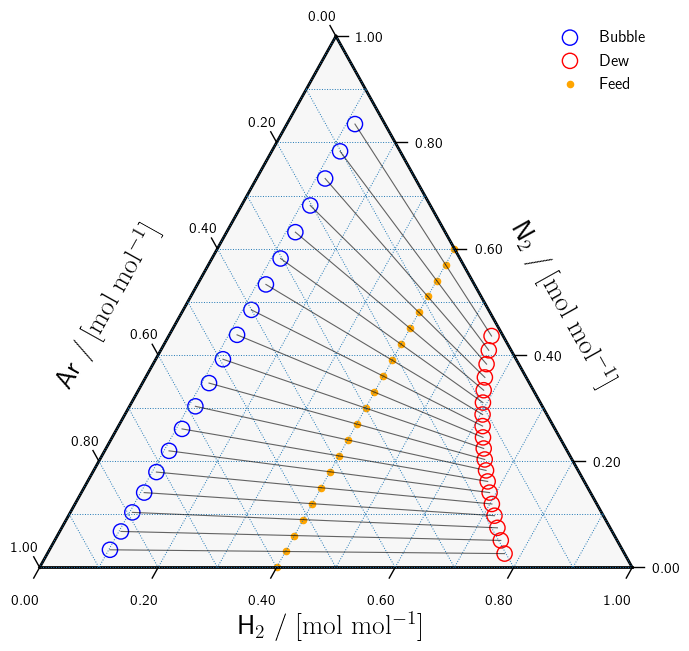

In [6]:

x_pts = [tuple(r[c] for c in ["x_Ar","x_N2","x_H2"]) for r in rows]
y_pts = [tuple(r[c] for c in ["y_Ar","y_N2","y_H2"]) for r in rows]

fig, tax = ternary.figure(scale=1.0, permutation='210')
# DEFAULT-ORDER: 012 - BOTTOM, LEFT, RIGHT
fig.set_size_inches(7, 6.5)

tax.boundary(linewidth=2)
tax.gridlines(multiple=0.1, linewidth=0.7)
# tax.convert_coordinates('blr')

tax.left_axis_label(r"Ar $/ \; [\mathrm{mol \; mol^{-1}}]$", offset=0.14, fontsize=20, fontweight="bold")
tax.right_axis_label(r"N$_2$ $/ \; [\mathrm{mol \; mol^{-1}}]$", offset=0.14, fontsize=20, fontweight="bold")
tax.bottom_axis_label(r"H$_2$ $/ \; [\mathrm{mol \; mol^{-1}}]$", offset=0.02, fontsize=20,fontweight="bold")

tax.ticks(axis="lbr",multiple=0.2,linewidth=1,fontsize=11,offset=0.02,tick_formats="%.2f")

tax.scatter(x_pts, marker="o", s=120, facecolors="none", edgecolors="blue", label="Bubble")
tax.scatter(y_pts, marker="o", s=120, facecolors="none", edgecolors="red", label="Dew")
tax.scatter(feeds, marker="o", s=20, facecolors="orange", edgecolors="orange", label="Feed")
# tax.scatter([(0.1, 0.4, 0.50)])

# Optional tie-lines for each case (can clutter if many)
for xp, yp in zip(x_pts, y_pts):
    tax.line(xp, yp, linewidth=0.8, color="k", alpha=0.6, permutation='210')

tax.get_axes().set_axis_off()
tax.clear_matplotlib_ticks()
tax.legend(loc="upper right", frameon=False, fontsize=12)

plt.tight_layout()
plt.show()

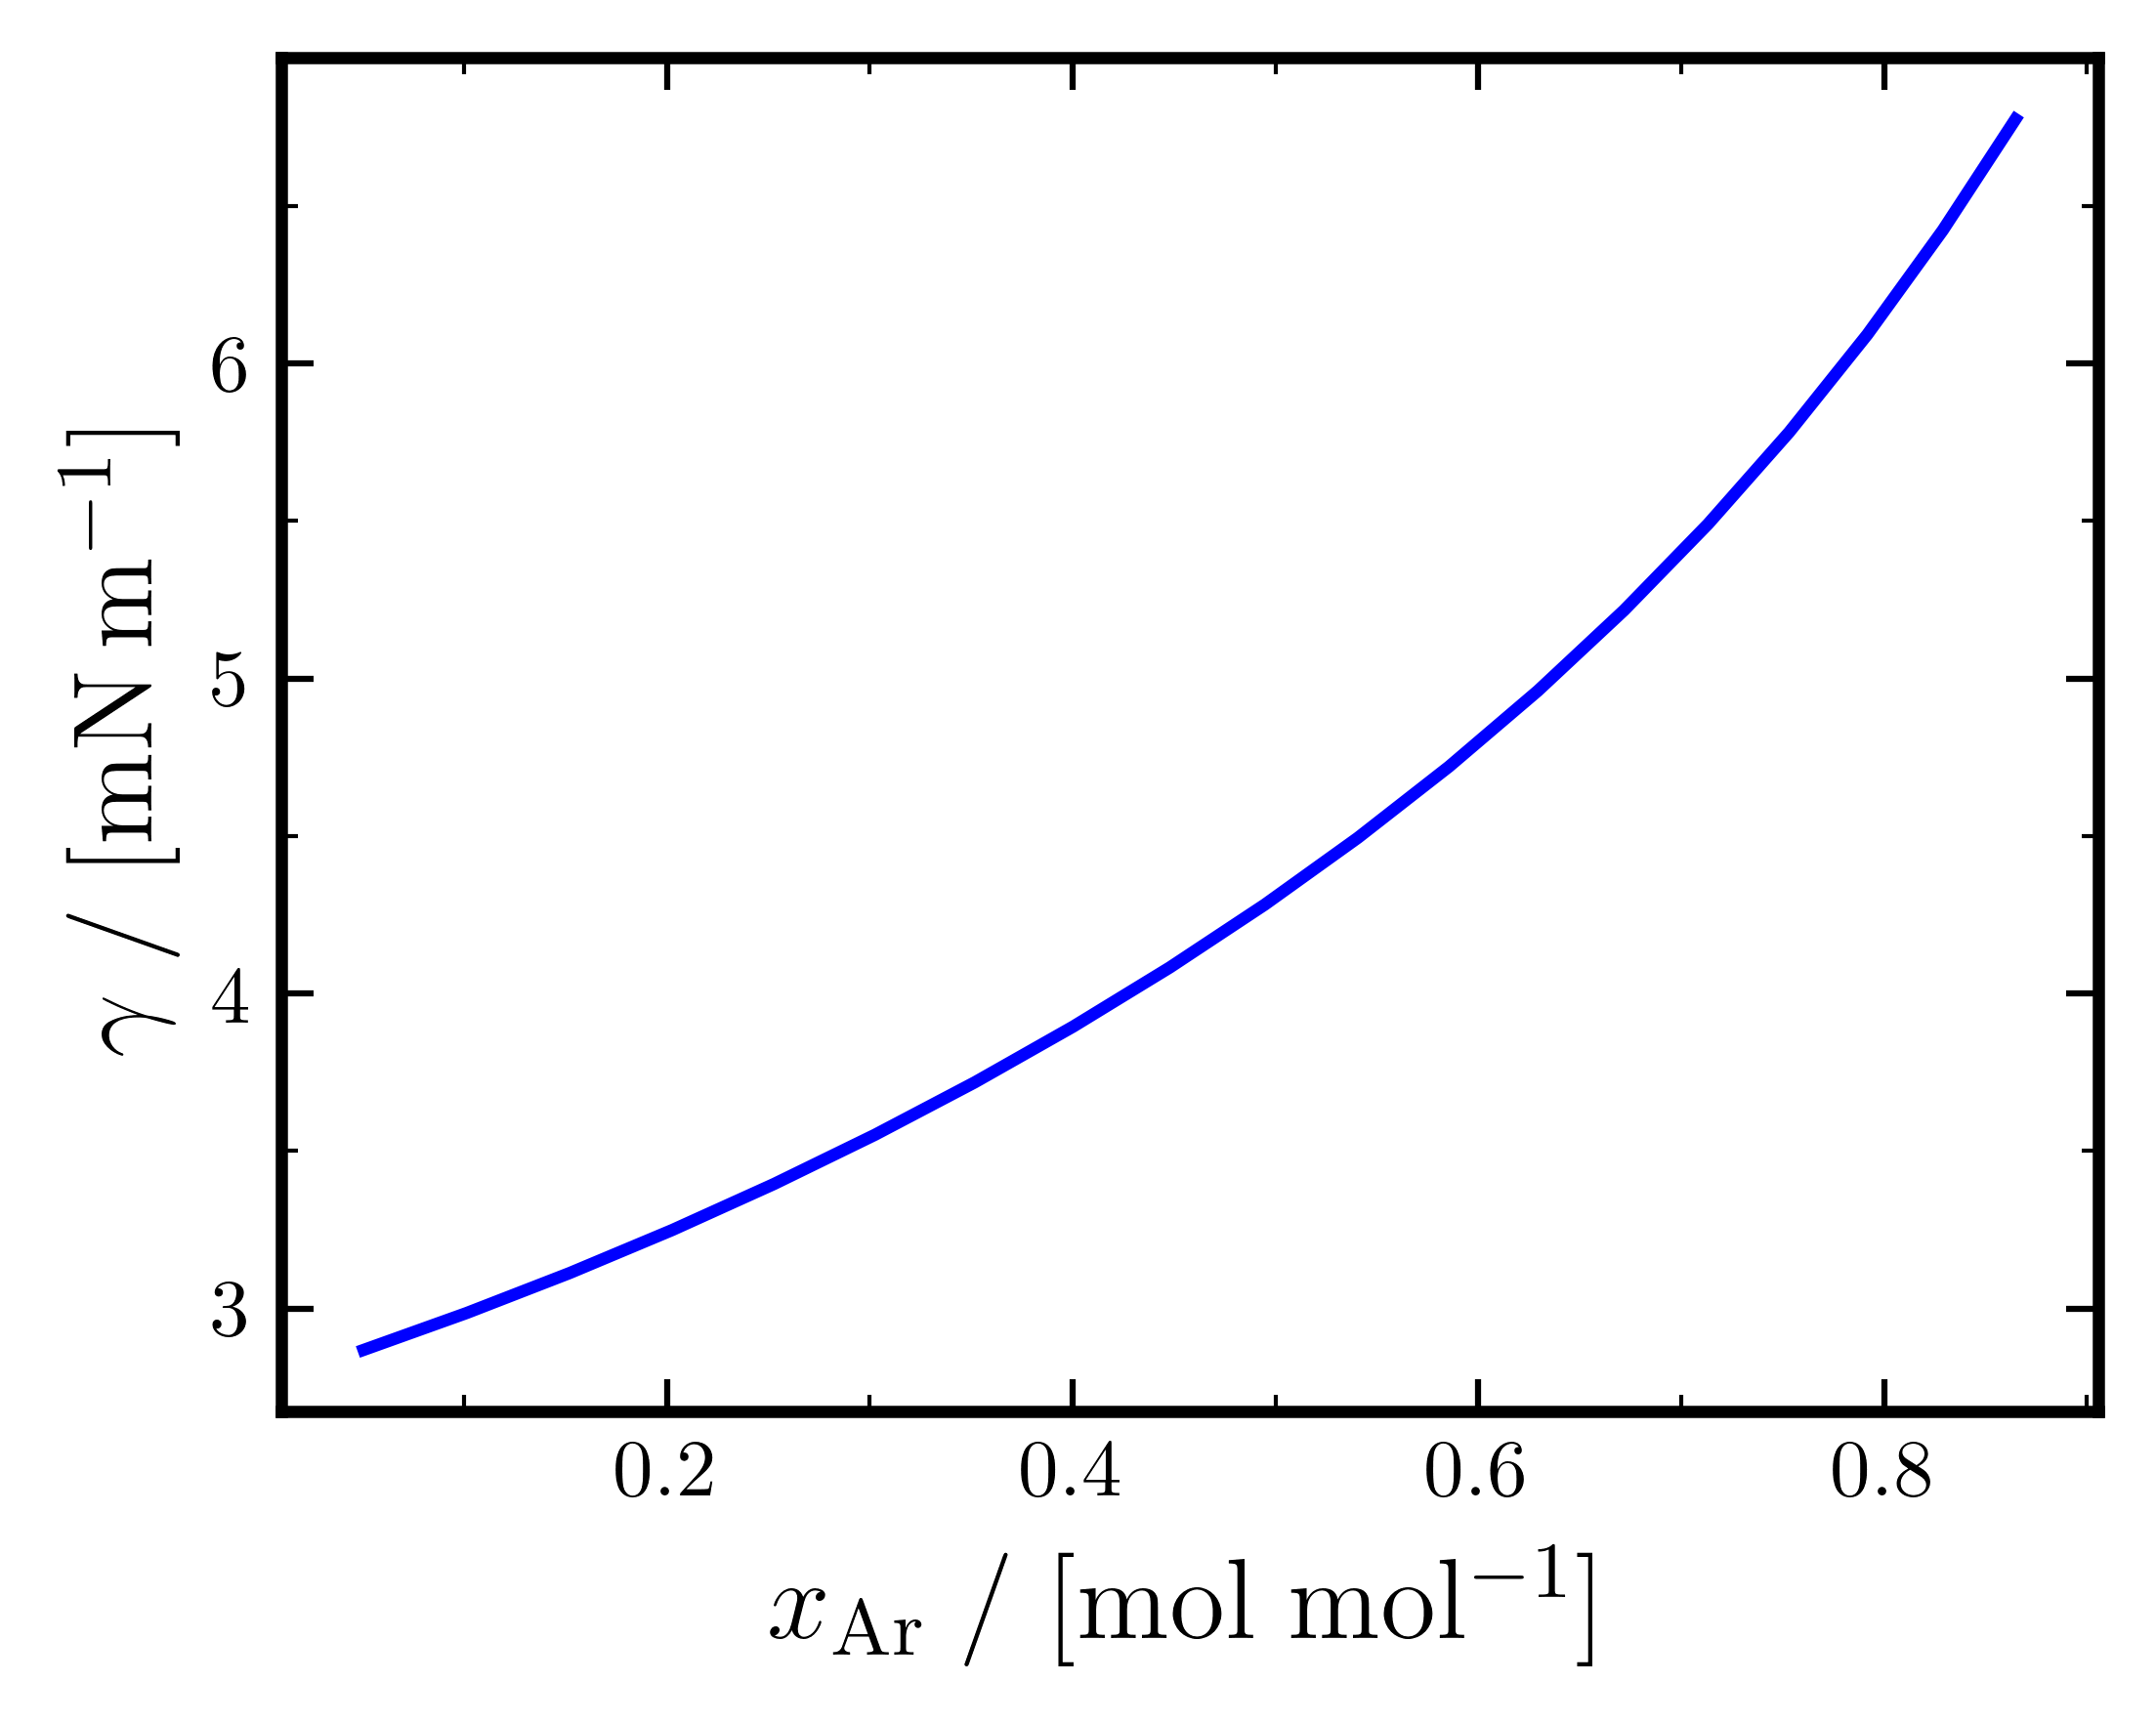

In [7]:
# IFT PLOT

fig1, ax1 = ps.plot_init()

ax1.plot(df["x_Ar"], df["gamma_mN_m"], marker=None, color="blue")

ax1.minorticks_on()
ax1.xaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax1.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax1.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

ax1.set_xlabel(r'$x_{\mathrm{Ar}} \; / \; [\mathrm{mol \; mol^{-1}}]$', fontsize=ps.label_fontsize)
ax1.set_ylabel(r'$\gamma \; / \; [\mathrm{mN\,m^{-1}}]$', fontsize=ps.label_fontsize)

plt.show()
save_plot(fig1, f'IFT_TM')
